# SkillCorner open data: loading and EDA

SkillCorner and PySport released broadcast tracking data for A-League Men matches from the 2024/25 season: [github.com/SkillCorner/opendata](https://github.com/SkillCorner/opendata). This notebook downloads it, loads each file type into pandas, and looks at what's actually in there.

The repo README says 10 matches, but `matches.json` lists 20. Each match folder has four files:

| File | What it holds |
|---|---|
| `{id}_match.json` | Lineups, minutes played, pitch size, which way each team attacks |
| `{id}_tracking_extrapolated.jsonl` | x/y for all 22 players and x/y/z for the ball, 10 frames per second |
| `{id}_dynamic_events.csv` | SkillCorner's derived events: possessions, passing options, off-ball runs, defensive engagements |
| `{id}_phases_of_play.csv` | Start and end frames of each phase (build-up, create, finish...) for both teams |

There are also three season-level CSVs in `data/aggregates/` (physical, off-ball runs, passing) covering every A-League player who played 60+ minutes in a game.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from mplsoccer import Pitch

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Home team gets blue, away team orange, everything else gray.
HOME, AWAY, GRAY, INK = "#2a78d6", "#eb6834", "#9a9893", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#b9b8b2",
    "axes.labelcolor": INK,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.6,
    "xtick.color": INK,
    "ytick.color": INK,
})

## Downloading

Everything except the tracking files can come straight from `raw.githubusercontent.com`. The tracking files are stored with Git LFS, so the raw URL only returns a 133-byte pointer file. The real files (around 90 MB each) live under `media.githubusercontent.com`.

`fetch` downloads a file once into `data/` at the repo root and reuses it after that.

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"

RAW_URL = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data"
LFS_URL = "https://media.githubusercontent.com/media/SkillCorner/opendata/master/data"


def fetch(path, lfs=False):
    """Download data/<path> from the SkillCorner repo unless it's already cached."""
    local = DATA_DIR / path
    if local.exists():
        return local
    local.parent.mkdir(parents=True, exist_ok=True)
    url = f"{LFS_URL if lfs else RAW_URL}/{path}"
    tmp = local.with_suffix(local.suffix + ".part")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    tmp.rename(local)
    return local

## 1. The match list

`matches.json` is a short list of match IDs with teams and kickoff times. Pass `encoding="utf-8"` whenever you open these JSON files. Windows defaults to cp1252, which turns names like Šušnjar into garbage.

In [3]:
with open(fetch("matches.json"), encoding="utf-8") as f:
    matches = pd.json_normalize(json.load(f))

matches = (
    matches.rename(columns={"home_team.short_name": "home", "away_team.short_name": "away"})
    .assign(date=lambda d: pd.to_datetime(d["date_time"]).dt.date)
    [["id", "date", "home", "away", "home_team.id", "away_team.id"]]
    .sort_values("date")
    .reset_index(drop=True)
)
print(len(matches), "matches")
matches

20 matches


,id,date,home,away,home_team.id,away_team.id
0,1874553,2024-11-23,Brisbane FC,Adelaide United,1802,866
1,1886347,2024-11-30,Auckland FC,Newcastle,4177,1805
2,1899585,2024-12-07,Auckland FC,Wellington P FC,4177,867
3,1925299,2024-12-21,Brisbane FC,Perth Glory,1802,871
4,1927964,2024-12-22,Western Sydney,Wellington P FC,2902,867
5,1953632,2024-12-31,CC Mariners,Melbourne City,870,2380
6,1959846,2025-01-10,Melbourne V FC,Western United,868,1803
7,1986691,2025-01-26,Western Sydney,Auckland FC,2902,4177
8,1996436,2025-02-01,Auckland FC,Macarthur FC,4177,1804
9,1996435,2025-02-01,Sydney FC,Adelaide United,869,866


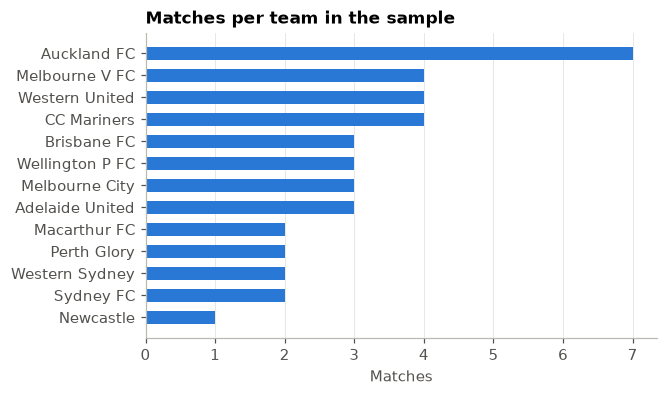

In [4]:
appearances = pd.concat([matches["home"], matches["away"]]).value_counts().sort_values()

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.barh(appearances.index, appearances.values, color=HOME, height=0.6)
ax.set_title("Matches per team in the sample")
ax.set_xlabel("Matches")
ax.grid(axis="y", visible=False)
plt.show()

The sample isn't balanced. Some teams show up much more than others, so anything summed across all 20 matches leans toward those teams.

## 2. One match in detail

Most of this notebook uses one match. Change `MATCH_ID` to any ID from the table above and everything below should still run.

In [5]:
MATCH_ID = 1886347

with open(fetch(f"matches/{MATCH_ID}/{MATCH_ID}_match.json"), encoding="utf-8") as f:
    meta = json.load(f)

home_name, away_name = meta["home_team"]["short_name"], meta["away_team"]["short_name"]
print(f"{home_name} {meta['home_team_score']}-{meta['away_team_score']} {away_name}")
print(f"{meta['stadium']['name']}, {meta['date_time'][:10]}")
print(f"Pitch: {meta['pitch_length']} x {meta['pitch_width']} m")
print("Home team attacks:", meta["home_team_side"], "(period 1, period 2)")
pd.DataFrame(meta["match_periods"])

Auckland FC 2-0 Newcastle
Mount Smart Stadium, 2024-11-30
Pitch: 104 x 68 m
Home team attacks: ['right_to_left', 'left_to_right'] (period 1, period 2)


,period,name,start_frame,end_frame,duration_frames,duration_minutes
0,1,period_1,10,27790,27780,46.3
1,2,period_2,27800,59060,31260,52.1


Two things matter for later. The pitch isn't always 105 x 68, so read the size from the file rather than hard-coding it. And `home_team_side` tells you which way the home team attacks in each half, which you need to flip the tracking coordinates.

The `players` list holds everyone in the squad, including unused subs. The `id` field is the one the tracking and event files use (not `trackable_object`).

In [6]:
def lineup_table(meta):
    rows = []
    for p in meta["players"]:
        total = p["playing_time"]["total"] or {}
        rows.append({
            "player_id": p["id"],
            "name": p["short_name"],
            "number": p["number"],
            "team": "home" if p["team_id"] == meta["home_team"]["id"] else "away",
            "role": p["player_role"]["acronym"],
            "starter": p["start_time"] == "00:00:00",
            "minutes": total.get("minutes_played", 0.0),
        })
    return pd.DataFrame(rows)


lineup = lineup_table(meta)
lineup.sort_values(["team", "starter", "minutes"], ascending=[False, False, False])

,player_id,name,number,team,role,starter,minutes
1,51713,C. Elliott,17,home,RB,True,98.40
4,133498,F. De Vries,15,home,LB,True,98.40
5,33697,N. Pijnaker,4,home,LCB,True,98.40
6,51667,D. Hall,23,home,RCB,True,98.40
7,14736,L. Verstraete,6,home,DM,True,98.40
18,965685,L. Gillion,14,home,LW,True,98.40
27,23418,F. Gallegos,28,home,AM,True,98.40
35,285188,A. Paulsen,12,home,GK,True,98.40
0,38673,G. May,10,home,CF,True,86.65
2,50951,J. Brimmer,22,home,CF,True,77.91


## 3. Tracking data

The tracking file is JSON Lines: one JSON object per frame. Each frame has a `period`, a `timestamp`, the ball's position, which team has possession, and a `player_data` list with x/y for each player.

Coordinates are in meters with (0, 0) at the center spot. x runs along the length of the pitch and y across it.

The loader below splits each frame into two tables: one row per frame (ball and possession) and one row per player per frame. Frames before kickoff have `period = None`, so it drops them. Parsing about 59,000 lines takes 20 seconds or so.

In [7]:
def load_tracking(path):
    frames, players = [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            fr = json.loads(line)
            if fr["period"] is None:
                continue
            ball = fr["ball_data"]
            frames.append((
                fr["frame"], fr["period"], fr["timestamp"],
                ball["x"], ball["y"], ball["z"], ball["is_detected"],
                fr["possession"]["group"], len(fr["player_data"]),
            ))
            for p in fr["player_data"]:
                players.append((fr["frame"], fr["period"], p["player_id"], p["x"], p["y"], p["is_detected"]))

    frames = pd.DataFrame(frames, columns=[
        "frame", "period", "timestamp", "ball_x", "ball_y", "ball_z",
        "ball_detected", "possession", "n_players",
    ])
    frames["period"] = frames["period"].astype(int)
    frames["seconds"] = pd.to_timedelta(frames["timestamp"]).dt.total_seconds()
    players = pd.DataFrame(players, columns=["frame", "period", "player_id", "x", "y", "is_detected"])
    return frames, players


frames, pos = load_tracking(fetch(f"matches/{MATCH_ID}/{MATCH_ID}_tracking_extrapolated.jsonl", lfs=True))
pos = pos.merge(lineup[["player_id", "name", "number", "team"]], on="player_id", how="left")
print(f"{len(frames):,} frames, {len(pos):,} player positions")
frames.head()

59,042 frames, 956,076 player positions


,frame,period,timestamp,ball_x,ball_y,ball_z,ball_detected,possession,n_players,seconds
0,10,1,00:00:00.00,0.32,0.38,0.13,True,NaN,22,0.0
1,11,1,00:00:00.10,0.54,0.08,0.22,True,NaN,22,0.1
2,12,1,00:00:00.20,0.57,-0.07,0.19,True,NaN,22,0.2
3,13,1,00:00:00.30,0.56,-0.07,0.14,True,NaN,22,0.3
4,14,1,00:00:00.40,0.59,-0.03,0.14,True,NaN,22,0.4


In [8]:
pos.head()

,frame,period,player_id,x,y,is_detected,name,number,team
0,10,1,51009,-39.63,-0.08,False,R. Scott,1,away
1,10,1,176224,-19.21,-9.18,True,P. Cancar,4,away
2,10,1,51649,-21.83,0.47,True,A. Šušnjar,15,away
3,10,1,50983,-1.16,-32.47,True,D. Ingham,14,away
4,10,1,735578,-18.88,15.73,True,M. Natta,33,away


### How much of the match is covered?

A broadcast camera can't see everything. During replays and close-ups SkillCorner has no view of the pitch, and the file has frames with an empty `player_data` list. The "extrapolated" in the file name covers the other case: when a player is out of shot but the camera is still on the game, SkillCorner estimates where they are and sets `is_detected` to `False`.

In [9]:
empty = frames["n_players"].eq(0)
print(f"Frames with no players at all: {empty.mean():.1%} ({empty.sum() / 600:.1f} minutes)")
print(f"Player positions actually seen on camera: {pos['is_detected'].mean():.1%}")
print(f"Frames where the ball has a position: {frames['ball_x'].notna().mean():.1%}")

# Group consecutive empty frames into gaps
gap_id = empty.ne(empty.shift()).cumsum()
gaps = frames[empty].groupby(gap_id[empty]).agg(start=("seconds", "first"), length_s=("frame", "size"))
gaps["length_s"] /= 10
print(f"\n{len(gaps)} gaps, median {gaps['length_s'].median():.0f} s, longest {gaps['length_s'].max():.0f} s")

Frames with no players at all: 26.4% (26.0 minutes)
Player positions actually seen on camera: 59.3%
Frames where the ball has a position: 73.6%

65 gaps, median 18 s, longest 116 s


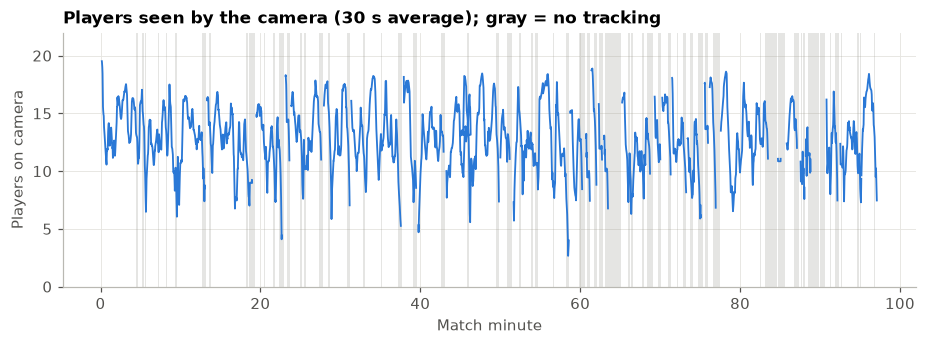

In [10]:
detected_per_frame = pos.groupby("frame")["is_detected"].sum()
timeline = frames.set_index("frame")[["seconds", "n_players"]].join(detected_per_frame.rename("detected"))
timeline.loc[timeline["n_players"] == 0, "detected"] = np.nan
timeline["detected_30s"] = timeline["detected"].rolling(300, min_periods=100).mean()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(timeline["seconds"] / 60, timeline["detected_30s"], color=HOME, lw=1.2)
for _, g in gaps.iterrows():
    ax.axvspan(g["start"] / 60, (g["start"] + g["length_s"]) / 60, color=GRAY, alpha=0.25, lw=0)
ax.set_ylim(0, 22)
ax.set_xlabel("Match minute")
ax.set_ylabel("Players on camera")
ax.set_title("Players seen by the camera (30 s average); gray = no tracking")
plt.show()

Across the match, 59% of player positions are seen on camera and the rest are estimates. That's fine for team shape but worth remembering before you trust one off-camera player's exact position. The camera follows the ball, so players far from it get estimated most: in this match the goalkeepers are on camera only 15% of the time and the centre-backs about half the time, against roughly 70% for midfielders and wingers.

### A single frame

mplsoccer has a `skillcorner` pitch type that matches this coordinate system. Hollow markers are extrapolated players. The cell below picks a frame where 14 players are on camera, so you can see both kinds.

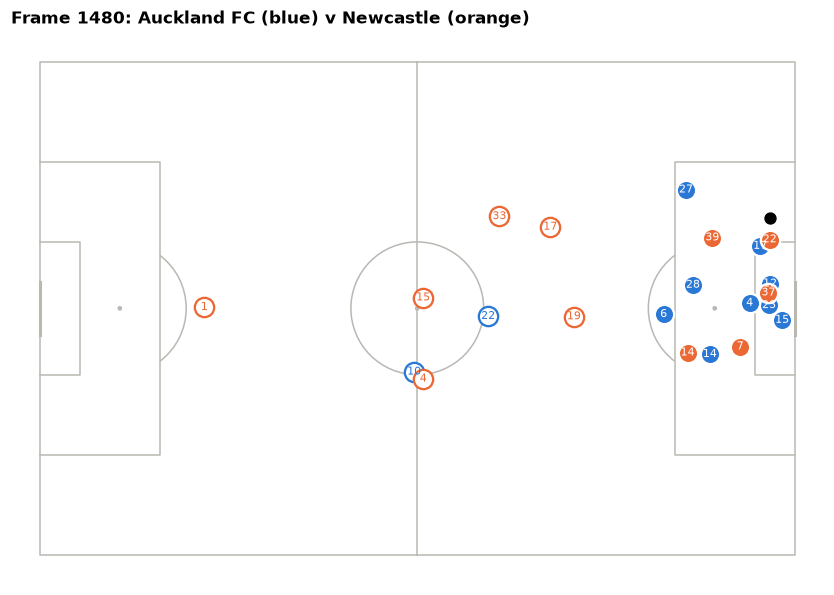

In [11]:
def draw_frame(frame_no, ax=None, title=None):
    pitch = Pitch(pitch_type="skillcorner", pitch_length=meta["pitch_length"],
                  pitch_width=meta["pitch_width"], line_color="#b9b8b2", linewidth=1)
    if ax is None:
        fig, ax = pitch.draw(figsize=(8, 5.5))
    else:
        pitch.draw(ax=ax)
    snap = pos[pos["frame"] == frame_no]
    for team, color in [("home", HOME), ("away", AWAY)]:
        t = snap[snap["team"] == team]
        seen, guessed = t[t["is_detected"]], t[~t["is_detected"]]
        ax.scatter(seen["x"], seen["y"], s=160, color=color, edgecolors="white", linewidths=1.5, zorder=3)
        ax.scatter(guessed["x"], guessed["y"], s=160, facecolors="white", edgecolors=color, linewidths=1.5, zorder=3)
        for _, p in t.iterrows():
            ax.text(p["x"], p["y"], int(p["number"]), ha="center", va="center", fontsize=7,
                    color="white" if p["is_detected"] else color, zorder=4)
    ball = frames.loc[frames["frame"] == frame_no].iloc[0]
    ax.scatter(ball["ball_x"], ball["ball_y"], s=50, color="black", zorder=5)
    ax.set_title(title or f"Frame {frame_no}", loc="left")
    return ax


example_frame = timeline.query("detected == 14").index[200]
draw_frame(example_frame, title=f"Frame {example_frame}: {home_name} (blue) v {away_name} (orange)")
plt.show()

### The ball

The ball has a height (`z`) as well as x/y. Most of the time it's on the ground.

ball_detected
True     0.822633
False    0.177367
Name: share of frames with a ball position, dtype: float64


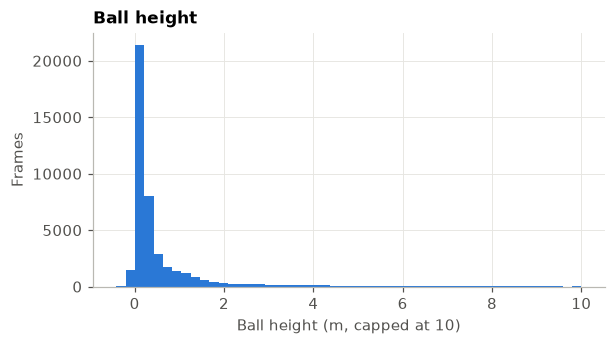

In [12]:
ball = frames.dropna(subset=["ball_z"])
print(ball["ball_detected"].value_counts(normalize=True).rename("share of frames with a ball position"))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(ball["ball_z"].clip(upper=10), bins=50, color=HOME)
ax.set_xlabel("Ball height (m, capped at 10)")
ax.set_ylabel("Frames")
ax.set_title("Ball height")
plt.show()

### Speed and distance

At 10 frames per second, speed is distance between consecutive frames times 10. Two details matter here:

- Only use pairs of frames that really are consecutive. A player who disappears for a 2-minute replay would otherwise "teleport" across the pitch.
- Group by period as well as player, so the half-time break doesn't count as a step.

The SkillCorner README says to smooth speeds yourself. Raw frame-to-frame speeds here top out around 14 m/s, which is faster than Usain Bolt (about 12.4 m/s), so a few spikes get through. A 1-second rolling average takes care of most of them.

In [13]:
pos = pos.sort_values(["player_id", "frame"]).reset_index(drop=True)
g = pos.groupby(["player_id", "period"])
consecutive = g["frame"].diff().eq(1)
pos["step"] = np.hypot(g["x"].diff(), g["y"].diff()).where(consecutive)
pos["speed"] = pos["step"] * 10  # m/s
pos["speed_1s"] = (
    pos.groupby(["player_id", "period"])["speed"]
    .transform(lambda s: s.rolling(10, min_periods=10).mean())
)
pos[["speed", "speed_1s"]].describe(percentiles=[0.5, 0.99, 0.999]).round(2)

,speed,speed_1s
count,954646.00,941776.00
mean,2.09,2.10
std,1.48,1.46
min,0.00,0.00
50%,1.73,1.75
99%,6.44,6.39
99.9%,7.94,7.86
max,14.00,12.45


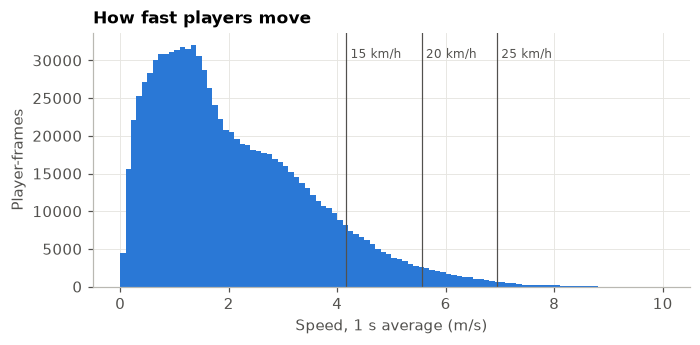

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(0, 10, 101)
ax.hist(pos["speed_1s"].dropna(), bins=bins, color=HOME)
for kmh, label in [(15, "15 km/h"), (20, "20 km/h"), (25, "25 km/h")]:
    ax.axvline(kmh / 3.6, color=INK, lw=0.8)
    ax.text(kmh / 3.6 + 0.08, ax.get_ylim()[1] * 0.9, label, fontsize=8, color=INK)
ax.set_xlabel("Speed, 1 s average (m/s)")
ax.set_ylabel("Player-frames")
ax.set_title("How fast players move")
plt.show()

The lines at 15, 20 and 25 km/h are SkillCorner's thresholds for running, high-speed running and sprinting. Most of a match happens below 2 m/s.

Now total distance per player. Since tracking is missing for a chunk of the match, a raw total undercounts. Meters per tracked minute is a fairer number, and the season aggregates report the same thing (`total_metersperminute_full_all`), so there's something to check against.

In [15]:
tracked = pos.dropna(subset=["step"])
per_player = tracked.groupby("player_id").agg(
    distance_km=("step", lambda s: s.sum() / 1000),
    tracked_min=("step", lambda s: len(s) / 600),
    top_speed_kmh=("speed_1s", lambda s: s.max() * 3.6),
)
per_player["m_per_min"] = per_player["distance_km"] * 1000 / per_player["tracked_min"]
per_player = lineup.merge(per_player, on="player_id")
per_player.query("minutes > 60").sort_values("m_per_min", ascending=False).round(1)

,player_id,name,number,team,role,starter,minutes,distance_km,tracked_min,top_speed_kmh,m_per_min
24,23418,F. Gallegos,28,home,AM,True,98.4,11.3,72.3,31.0,156.4
3,50978,C. Timmins,19,away,LDM,True,86.3,10.0,65.4,33.5,152.9
7,14736,L. Verstraete,6,home,DM,True,98.4,10.8,72.3,27.3,148.9
25,795507,L. Bayliss,37,away,AM,True,61.6,7.5,50.9,27.5,147.7
23,133501,L. Rogerson,27,home,RW,True,71.2,8.1,55.4,30.7,145.7
15,965685,L. Gillion,14,home,LW,True,98.4,10.3,72.3,44.8,142.1
8,735573,T. Aquilina,39,away,LW,True,98.4,10.3,72.3,30.5,141.8
12,735574,K. Grozos,17,away,RDM,True,98.4,10.0,72.3,30.5,138.0
26,795505,E. Adams,7,away,RW,True,86.3,8.9,65.4,31.8,136.0
2,50951,J. Brimmer,22,home,CF,True,77.9,8.1,59.7,37.0,135.3


The top speeds need a second look. Most land between 27 and 37 km/h, but L. Gillion shows about 45 km/h, which no footballer reaches. Even after smoothing, a jump in an estimated position can create a fake sprint. If top speed matters for your work, use a high percentile instead of the max, or drop frames where the player isn't detected.

Season aggregates come in later, but here's the quick sanity check now: compare each player's meters per minute in this match with their season average from SkillCorner's own physical file. A player can have more than one row in that file (one per team and position group), so this takes a minutes-weighted average.

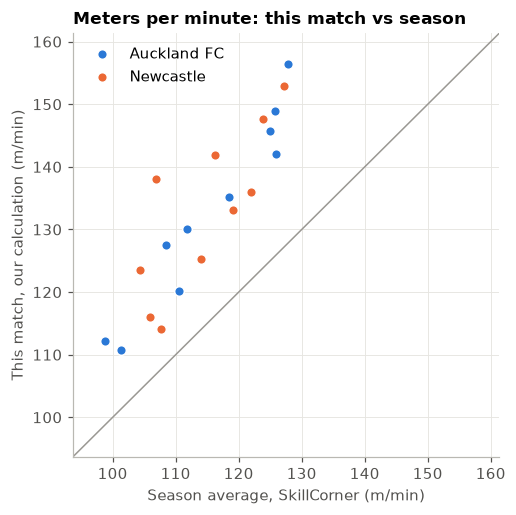

Correlation: 0.90


In [16]:
physical = pd.read_csv(fetch("aggregates/aus1league_physicalaggregates_20242025.csv"))

season_mpm = (
    physical.assign(w=physical["count_match"])
    .groupby("player_id")
    .apply(lambda d: np.average(d["total_metersperminute_full_all"], weights=d["w"]), include_groups=False)
    .rename("season_m_per_min")
)
check = per_player.query("minutes > 60").join(season_mpm, on="player_id").dropna(subset=["season_m_per_min"])

fig, ax = plt.subplots(figsize=(5, 5))
for team, color in [("home", HOME), ("away", AWAY)]:
    t = check[check["team"] == team]
    ax.scatter(t["season_m_per_min"], t["m_per_min"], color=color, s=40, edgecolors="white", linewidths=1,
               label=home_name if team == "home" else away_name)
lims = [check[["season_m_per_min", "m_per_min"]].min().min() - 5, check[["season_m_per_min", "m_per_min"]].max().max() + 5]
ax.plot(lims, lims, color=GRAY, lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Season average, SkillCorner (m/min)")
ax.set_ylabel("This match, our calculation (m/min)")
ax.set_title("Meters per minute: this match vs season")
ax.legend(frameon=False)
plt.show()
print(f"Correlation: {check['season_m_per_min'].corr(check['m_per_min']):.2f}")

The gray line is where the two would match exactly. The ranking agrees well (correlation 0.90), but every player sits 10 to 25 m/min above the line. That's the tracking gaps again: they mostly fall during replays and stoppages, when players are walking, so dividing by tracked minutes leaves out a lot of slow time. Treat the per-match numbers as relative, not as something to compare directly with SkillCorner's season figures.

### Team shape in and out of possession

Tracking coordinates aren't normalized: each team switches ends at half-time. To compare halves, flip x and y for whichever team is attacking right-to-left in that period, so both teams always attack toward the right.

The frame table has a `possession` column (`"home team"` / `"away team"`), so the average positions can be split by who has the ball.

In [17]:
def attacks_left(team, period):
    home_side = meta["home_team_side"][period - 1]
    home_left = home_side == "right_to_left"
    return home_left if team == "home" else not home_left


flip = np.where([attacks_left(t, p) for t, p in zip(pos["team"], pos["period"])], -1, 1)
pos["x_norm"] = pos["x"] * flip
pos["y_norm"] = pos["y"] * flip
pos = pos.merge(frames[["frame", "possession"]], on="frame", how="left")

pos[["team", "period", "x", "x_norm"]].groupby(["team", "period"]).mean().round(1)

x  x_norm
team period              
away 1      -12.6   -12.6
     2       15.0   -15.0
home 1        0.2    -0.2
     2        2.0     2.0

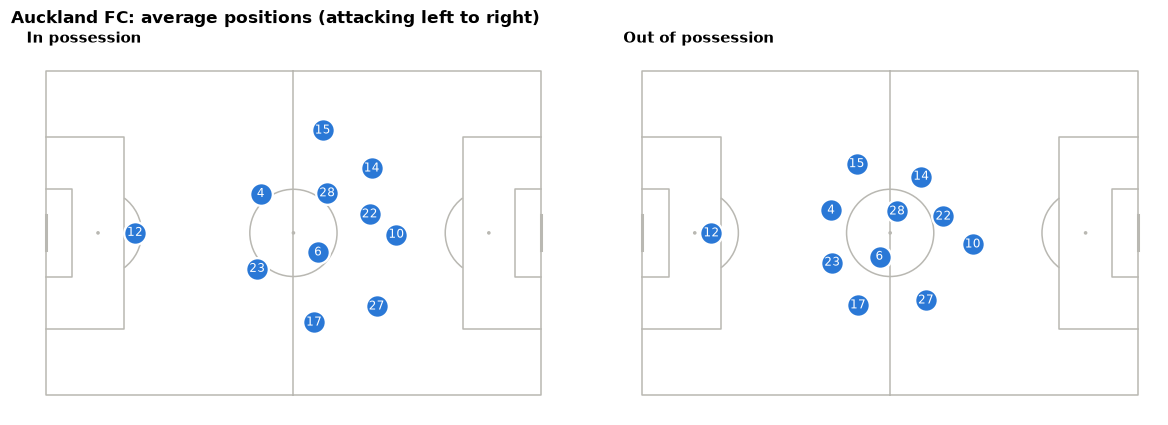

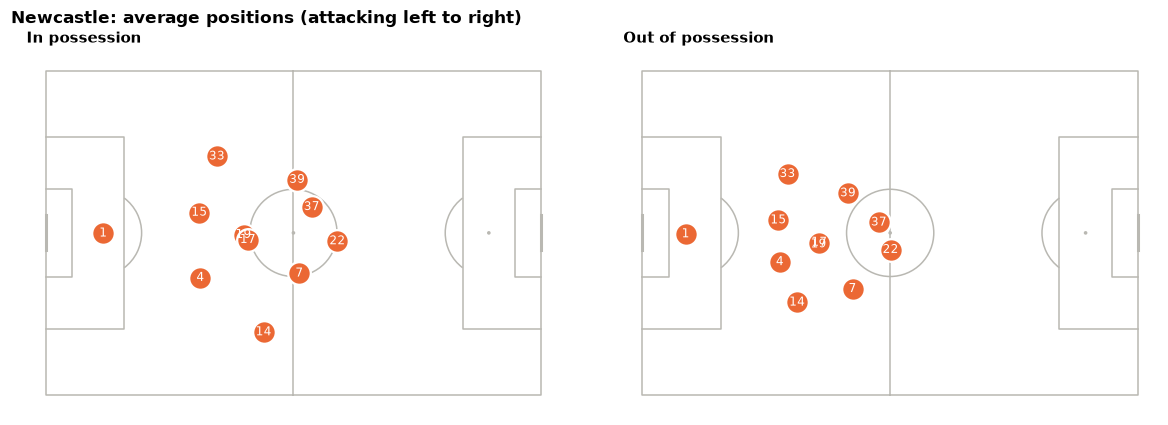

In [18]:
starters = lineup.loc[lineup["starter"], "player_id"]
pitch = Pitch(pitch_type="skillcorner", pitch_length=meta["pitch_length"],
              pitch_width=meta["pitch_width"], line_color="#b9b8b2", linewidth=1)

for team, color, name in [("home", HOME, home_name), ("away", AWAY, away_name)]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    fig.suptitle(f"{name}: average positions (attacking left to right)", x=0.02, ha="left", fontsize=11, fontweight="bold")
    own = "home team" if team == "home" else "away team"
    for ax, (label, in_poss) in zip(axes, [("In possession", True), ("Out of possession", False)]):
        pitch.draw(ax=ax)
        sub = pos[(pos["team"] == team) & pos["player_id"].isin(starters) & pos["possession"].notna()]
        sub = sub[(sub["possession"] == own) == in_poss]
        avg = sub.groupby(["player_id", "number"])[["x_norm", "y_norm"]].mean().reset_index()
        ax.scatter(avg["x_norm"], avg["y_norm"], s=220, color=color, edgecolors="white", linewidths=1.5, zorder=3)
        for _, p in avg.iterrows():
            ax.text(p["x_norm"], p["y_norm"], int(p["number"]), ha="center", va="center", color="white", fontsize=8, zorder=4)
        ax.set_title(label, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

Starting XI only. Auckland's centre-backs (4 and 23) average a spot near the halfway line when they have the ball. Newcastle's (15 and 4) stay around 20 m deeper with or without it, which fits a team that spent the match pinned back and lost 2-0.

## 4. Dynamic events

This is SkillCorner's own event layer, built from the tracking data rather than from a human tagger. It's wide: one row per event, over 300 columns.

In [19]:
de = pd.read_csv(fetch(f"matches/{MATCH_ID}/{MATCH_ID}_dynamic_events.csv"), low_memory=False)
print(de.shape)
de["event_type"].value_counts()

(5115, 322)


event_type
passing_option        2573
player_possession      990
on_ball_engagement     957
off_ball_run           595
Name: count, dtype: int64

There are four event types:

- `player_possession`: a player has the ball, from first touch to the moment they lose it. It records how the possession ended (pass, shot, loss...) and the pressure on the player.
- `passing_option`: a teammate who was available for a pass during a possession, whether or not they got the ball. It's the most common row type by a distance.
- `off_ball_run`: a run by a player without the ball, typed as `behind`, `coming_short`, `overlap` and so on.
- `on_ball_engagement`: a defender pressing or pressuring the player on the ball.

Most columns only apply to one event type, so the table is mostly empty. Count how many columns each type actually fills:

In [20]:
filled = (
    de.groupby("event_type")
    .apply(lambda d: d.notna().mean().gt(0.5).sum(), include_groups=False)
    .rename("columns more than half filled")
)
filled.to_frame()

,columns more than half filled
event_type,
off_ball_run,112
on_ball_engagement,122
passing_option,123
player_possession,195


In practice it's easier to split by type and drop the columns that are entirely empty for that type.

In [21]:
by_type = {t: d.dropna(axis=1, how="all") for t, d in de.groupby("event_type")}
{t: d.shape for t, d in by_type.items()}

{'off_ball_run': (595, 118),
 'on_ball_engagement': (957, 143),
 'passing_option': (2573, 147),
 'player_possession': (990, 209)}

### Event coordinates are already normalized

Unlike the tracking, event x/y are flipped so the team in possession always attacks toward +x. Shots prove it: every shot ends at positive x, whichever direction the team was playing in that half.

In [22]:
poss = by_type["player_possession"]
poss[poss["end_type"] == "shot"].groupby(["period", "attacking_side"])["x_end"].agg(["count", "min", "max"])

count    min    max
period attacking_side                     
1      left_to_right       4  29.11  44.56
       right_to_left       8  24.87  47.33
2      left_to_right      10  29.59  51.71
       right_to_left       5  16.99  44.91

### Possessions

How do possessions end, and how often do passes find a teammate?

In [23]:
print(poss["end_type"].value_counts().to_string(), "\n")
print(poss.groupby("team_shortname")["pass_outcome"].value_counts(normalize=True).unstack().round(3))

end_type
pass               852
possession_loss     77
shot                27
foul_suffered       18
clearance           14
unknown              2 

pass_outcome    offside  successful  unsuccessful
team_shortname                                   
Auckland FC         NaN       0.854         0.146
Newcastle         0.005       0.873         0.122


### Off-ball runs and pressing

The run and engagement subtypes are where this data goes beyond normal event data.

Auckland won 2-0 but completed a slightly lower share of their passes than Newcastle (85% vs 87%). Pass completion on its own says little about who played better.

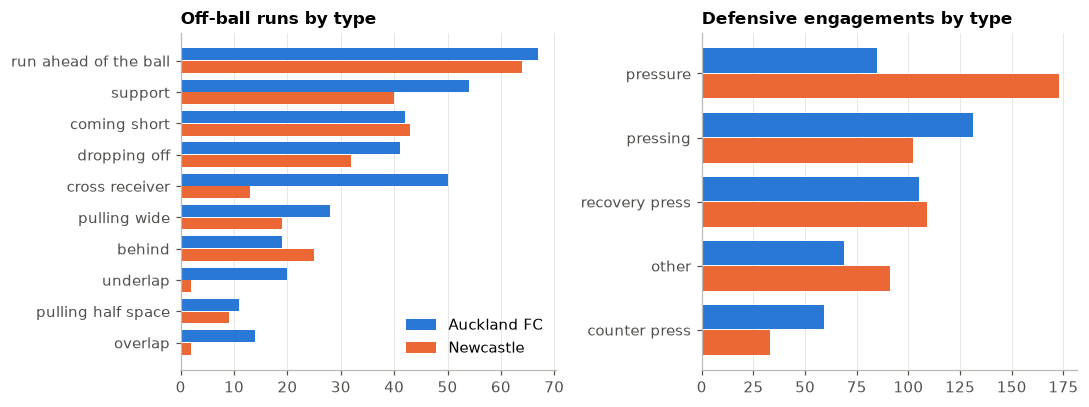

In [24]:
runs = by_type["off_ball_run"]
engagements = by_type["on_ball_engagement"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, df, title in [(axes[0], runs, "Off-ball runs by type"), (axes[1], engagements, "Defensive engagements by type")]:
    counts = df.groupby(["event_subtype", "team_shortname"]).size().unstack(fill_value=0)
    counts = counts.loc[counts.sum(axis=1).sort_values().index, [home_name, away_name]]
    y = np.arange(len(counts))
    ax.barh(y + 0.2, counts[home_name], height=0.38, color=HOME, label=home_name)
    ax.barh(y - 0.2, counts[away_name], height=0.38, color=AWAY, label=away_name)
    ax.set_yticks(y, counts.index.str.replace("_", " "))
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
axes[0].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

Two gaps stand out. Auckland made 50 cross-receiver runs to Newcastle's 13, and Newcastle's defenders logged about twice as many "pressure" engagements (closing down without a full press). Both fit a team that spent long spells defending its own box.

Each run has a start and end location, so they can go straight on a pitch. Here are the runs in behind, colored by whether the runner got the ball.

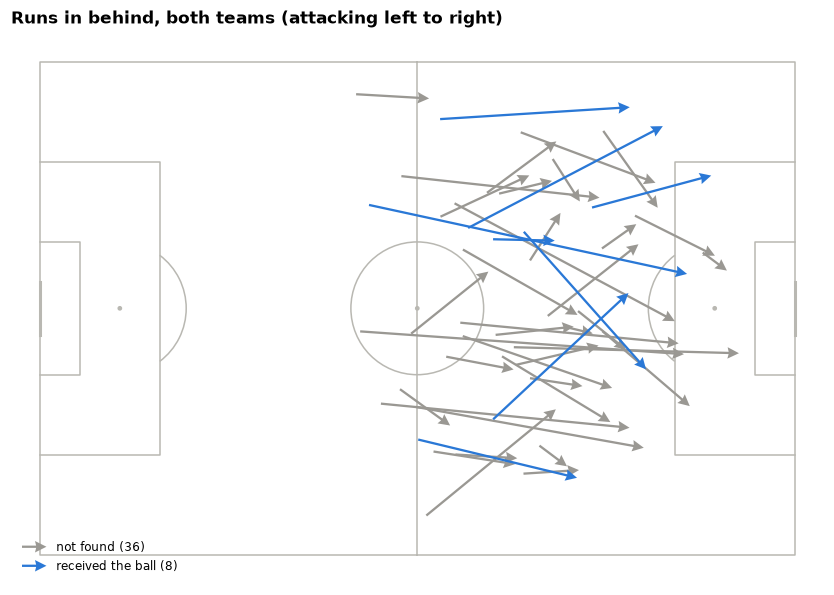

In [25]:
behind = runs[runs["event_subtype"] == "behind"]
pitch = Pitch(pitch_type="skillcorner", pitch_length=meta["pitch_length"],
              pitch_width=meta["pitch_width"], line_color="#b9b8b2", linewidth=1)
fig, ax = pitch.draw(figsize=(8, 5.5))
for received, color, label in [(False, GRAY, "not found"), (True, HOME, "received the ball")]:
    r = behind[behind["received"].fillna(False).astype(bool) == received]
    pitch.arrows(r["x_start"], r["y_start"], r["x_end"], r["y_end"], ax=ax, color=color,
                 width=1.5, headwidth=5, headlength=5, label=f"{label} ({len(r)})")
ax.legend(frameon=False, loc="lower left", fontsize=8)
ax.set_title(f"Runs in behind, both teams (attacking left to right)", loc="left")
plt.show()

### Pressure and pass completion, across all 20 matches

One match is too small for some questions, so load the events for every match. That's about 90 MB of CSV and it takes a minute the first time.

`overall_pressure_start` rates how much pressure the player was under when they got the ball, on a five-step scale.

In [26]:
all_de = pd.concat(
    [pd.read_csv(fetch(f"matches/{m}/{m}_dynamic_events.csv"), low_memory=False) for m in matches["id"]],
    ignore_index=True,
)
print(f"{len(all_de):,} events across {all_de['match_id'].nunique()} matches")

94,361 events across 20 matches


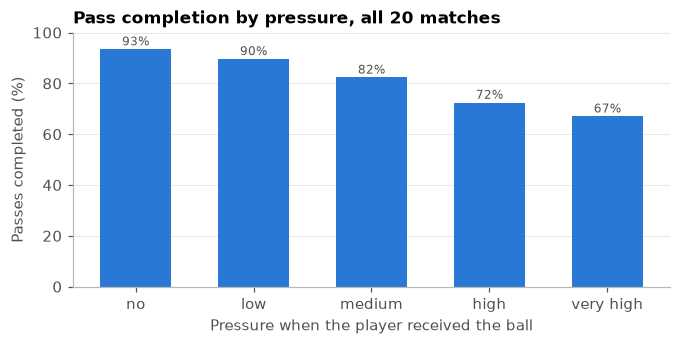

,mean,size
overall_pressure_start,,
no_pressure,0.934242,4623
low_pressure,0.895961,3268
medium_pressure,0.823122,3754
high_pressure,0.724240,2368
very_high_pressure,0.670139,288


In [27]:
pressure_order = ["no_pressure", "low_pressure", "medium_pressure", "high_pressure", "very_high_pressure"]
is_pass = (all_de["event_type"] == "player_possession") & (all_de["end_type"] == "pass")
passes = all_de.loc[is_pass, ["overall_pressure_start", "pass_outcome"]]
by_pressure = (
    passes.assign(completed=passes["pass_outcome"].eq("successful"))
    .groupby("overall_pressure_start")["completed"]
    .agg(["mean", "size"])
    .reindex(pressure_order)
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(by_pressure)), by_pressure["mean"] * 100, color=HOME, width=0.6)
for i, (rate, n) in enumerate(zip(by_pressure["mean"], by_pressure["size"])):
    ax.text(i, rate * 100 + 1.5, f"{rate:.0%}", ha="center", fontsize=8, color=INK)
ax.set_xticks(range(len(by_pressure)), [p.replace("_pressure", "").replace("_", " ") for p in by_pressure.index])
ax.set_ylim(0, 100)
ax.set_ylabel("Passes completed (%)")
ax.set_xlabel("Pressure when the player received the ball")
ax.set_title("Pass completion by pressure, all 20 matches")
ax.grid(axis="x", visible=False)
plt.show()
by_pressure

Completion drops steadily as pressure rises, from 93% with no pressure to 67% under very high pressure. The very-high bucket only holds 288 passes, so that last bar is the shakiest. The 1,771 passes with no pressure rating are left out.

## 5. Phases of play

The phases file splits ball-in-play time into chunks. Each row gives the phase of the team with the ball (build-up, create, finish, direct, transition...) and what the other team is doing (high block, medium block, low block...). It's small, so load all 20 matches.

In [28]:
phases = pd.concat(
    [pd.read_csv(fetch(f"matches/{m}/{m}_phases_of_play.csv")) for m in matches["id"]],
    ignore_index=True,
)
print(phases.shape)
phases[["match_id", "frame_start", "frame_end", "duration", "team_in_possession_shortname",
        "team_in_possession_phase_type", "team_out_of_possession_phase_type"]].head()

(8834, 44)


,match_id,frame_start,frame_end,duration,team_in_possession_shortname,team_in_possession_phase_type,team_out_of_possession_phase_type
0,1874553,29,122,9.3,Brisbane FC,create,medium_block
1,1874553,122,182,6.0,Brisbane FC,finish,low_block
2,1874553,182,257,7.5,Adelaide United,chaotic,chaotic
3,1874553,257,305,4.8,Brisbane FC,chaotic,chaotic
4,1874553,305,387,8.2,Adelaide United,finish,low_block


In [29]:
phases.groupby("team_in_possession_phase_type")["duration"].agg(["count", "median", "sum"]).sort_values("sum", ascending=False).round(1)

,count,median,sum
team_in_possession_phase_type,,,
create,2880,6.3,24906.9
finish,1623,6.1,13883.2
build_up,1196,6.9,10313.7
chaotic,1802,2.9,5985.6
set_play,360,4.8,2514.8
direct,677,3.2,2283.5
transition,185,11.4,2216.0
quick_break,111,8.5,1007.4


Pairing the two columns shows they aren't independent. Each in-possession phase maps to exactly one defensive phase: build-up always faces a high block, create faces a medium block, finish faces a low block. So the two labels describe the same moment from each side.

In [30]:
pd.crosstab(phases["team_in_possession_phase_type"], phases["team_out_of_possession_phase_type"])

team_out_of_possession_phase_type,chaotic,defending_direct,defending_quick_break,defending_set_play,defending_transition,high_block,low_block,medium_block
team_in_possession_phase_type,,,,,,,,
build_up,0,0,0,0,0,1196,0,0
chaotic,1802,0,0,0,0,0,0,0
create,0,0,0,0,0,0,0,2880
direct,0,677,0,0,0,0,0,0
finish,0,0,0,0,0,0,1623,0
quick_break,0,0,111,0,0,0,0,0
set_play,0,0,0,360,0,0,0,0
transition,0,0,0,0,185,0,0,0


How does each team spend its time on the ball? Share of in-possession time by phase type, per team:

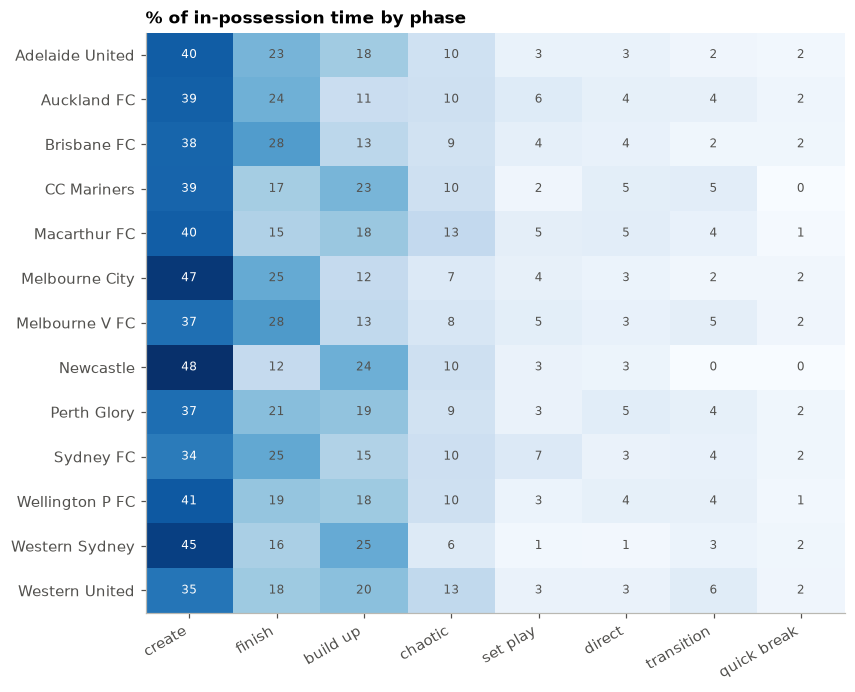

In [31]:
def share_heatmap(col, team_col, title):
    share = phases.pivot_table(index=team_col, columns=col, values="duration", aggfunc="sum", fill_value=0)
    share = share.div(share.sum(axis=1), axis=0) * 100
    share = share[share.mean().sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(1 + 0.9 * share.shape[1], 0.45 * len(share) + 1))
    im = ax.imshow(share.values, cmap="Blues", aspect="auto", vmin=0)
    ax.set_xticks(range(share.shape[1]), share.columns.str.replace("_", " "), rotation=30, ha="right")
    ax.set_yticks(range(len(share)), share.index)
    for i in range(share.shape[0]):
        for j in range(share.shape[1]):
            v = share.values[i, j]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if v > share.values.max() * 0.6 else INK)
    ax.grid(False)
    ax.set_title(title)
    plt.show()
    return share


in_poss_share = share_heatmap("team_in_possession_phase_type", "team_in_possession_shortname",
                              "% of in-possession time by phase")

Create is the biggest share for everyone. The differences show up further down: Western Sydney and Newcastle spent about a quarter of their time on the ball in build-up, while Melbourne City spent less there and more in create. Newcastle's 0% for transition and quick break comes from a single match, so don't read much into it.

The same view for defending. Because the phases pair up one-to-one, this is the mirror image: a team's high-block share is how much time its opponents spent building up. The file doesn't name the defending team, so it's worked out from the match list.

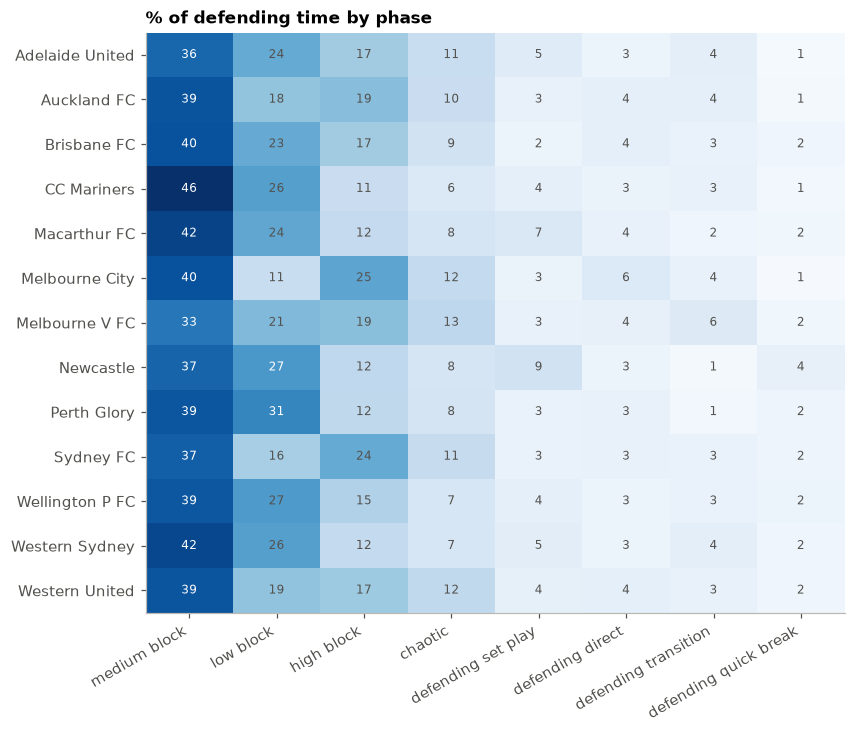

In [32]:
teams_by_match = matches.set_index("id")[["home", "away"]]
other = phases.join(teams_by_match, on="match_id")
phases["team_out_of_possession_shortname"] = np.where(
    other["team_in_possession_shortname"] == other["home"], other["away"], other["home"]
)
out_poss_share = share_heatmap("team_out_of_possession_phase_type", "team_out_of_possession_shortname",
                               "% of defending time by phase")

With some teams in only two or three matches, read these as descriptions of those games, not of each team's season.

## 6. Season aggregates

The three aggregate files cover the whole 2024/25 A-League season, not just the 20 sample matches. They only count performances of 60+ minutes.

A player can have several rows: one per team and position group. T. Aquilina, for example, has four rows for Newcastle (central defender, full back, midfield, wide attacker). Group by `player_id` if you want one row per player.

In [33]:
print(physical.shape, "rows,", physical["player_id"].nunique(), "players")
physical.loc[physical["player_short_name"] == "T. Aquilina",
             ["player_short_name", "team_name", "position_group", "count_match", "minutes_full_all"]]

(406, 65) rows, 268 players


,player_short_name,team_name,position_group,count_match,minutes_full_all
270,T. Aquilina,Newcastle United Jets FC,Central Defender,1,98.65
271,T. Aquilina,Newcastle United Jets FC,Full Back,10,98.59
272,T. Aquilina,Newcastle United Jets FC,Midfield,1,98.20
273,T. Aquilina,Newcastle United Jets FC,Wide Attacker,13,95.22


Most physical columns come in three versions: `_full_all` (whole match), `_full_tip` (team in possession) and `_full_otip` (other team in possession). Counts and distances are per-match averages. `psv99` is SkillCorner's top-speed measure, in km/h.

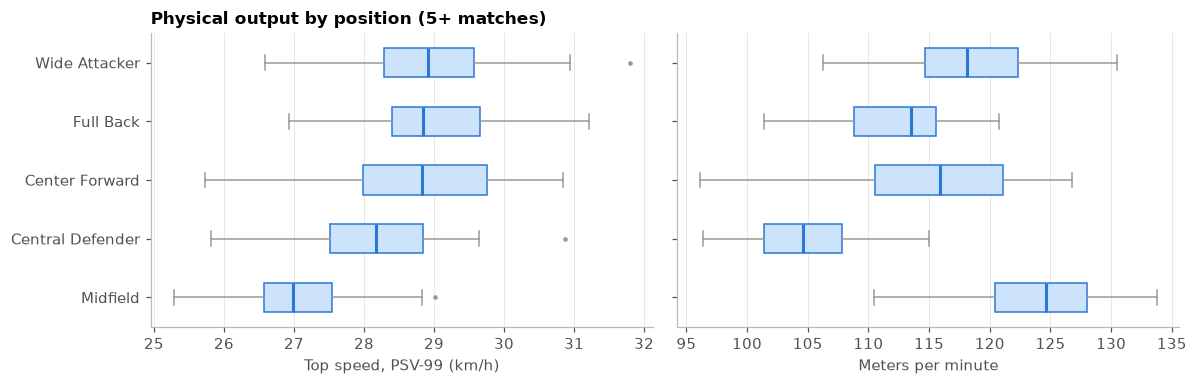

In [34]:
regular = physical[physical["count_match"] >= 5]
groups = regular.groupby("position_group")["psv99"].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, col, label in [(axes[0], "psv99", "Top speed, PSV-99 (km/h)"),
                       (axes[1], "total_metersperminute_full_all", "Meters per minute")]:
    data = [regular.loc[regular["position_group"] == g, col] for g in groups]
    ax.boxplot(data, orientation="horizontal", widths=0.5, patch_artist=True,
               boxprops=dict(facecolor="#cde2fb", edgecolor=HOME), medianprops=dict(color=HOME, lw=2),
               whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
               flierprops=dict(marker="o", markersize=3, markerfacecolor=GRAY, markeredgecolor="none"))
    ax.set_yticks(range(1, len(groups) + 1), groups)
    ax.set_xlabel(label)
    ax.grid(axis="y", visible=False)
axes[0].set_title("Physical output by position (5+ matches)")
plt.tight_layout()
plt.show()

In [35]:
cols = ["player_short_name", "team_name", "position_group", "count_match", "psv99",
        "sprint_count_full_all", "hi_distance_full_all"]
regular.sort_values("psv99", ascending=False)[cols].head(10)

,player_short_name,team_name,position_group,count_match,psv99,sprint_count_full_all,hi_distance_full_all
281,Clarismario Rodrigues,Melbourne Victory Football Club,Wide Attacker,9,31.80,16.22,994.44
130,D. Pierias,Adelaide United Football Club,Full Back,22,31.21,16.68,1061.45
235,J. Drew,Macarthur FC,Wide Attacker,10,30.94,15.20,912.40
64,N. Mileusnić,Perth Glory Football Club,Wide Attacker,7,30.91,13.57,941.43
170,D. Hall,Auckland FC,Central Defender,15,30.87,7.80,486.67
44,P. Klimala,Sydney Football Club,Center Forward,19,30.84,12.58,733.95
318,M. Ruhs,Western United,Center Forward,5,30.50,13.60,854.60
56,J. Geria,Melbourne Victory Football Club,Full Back,12,30.50,14.25,866.67
189,W. Scott,Macarthur FC,Full Back,7,30.43,14.57,992.29
178,A. Goodwin,Adelaide United Football Club,Center Forward,16,30.42,11.44,723.44


The passing aggregates share the same keys (`player_id`, `team_id`, `position_group`). One question they can answer: who completes more passes than the difficulty of their passes would predict? `pass_avgxpass_attempted` is the average expected completion of a player's passes, so a player above the diagonal completes more than expected.

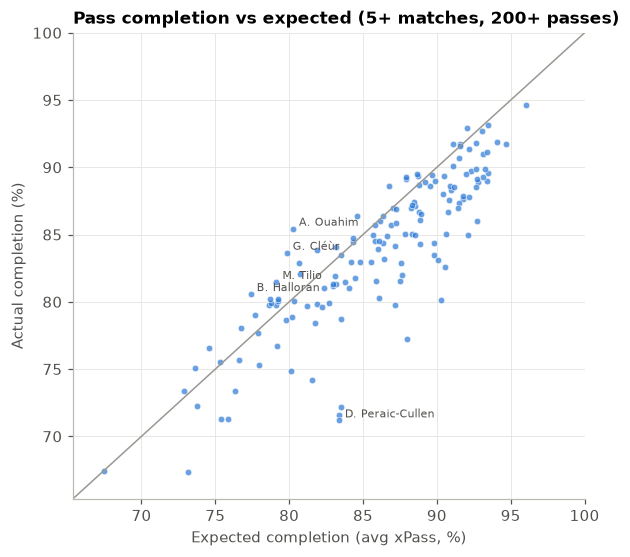

147 player rows


In [36]:
passing = pd.read_csv(fetch("aggregates/aus1league_passingaggregates_20242025.csv"))
p = passing[(passing["performance_count"] >= 5) & (passing["pass_count_attempted_total"] >= 200)].copy()
p["xpass_pct"] = p["pass_avgxpass_attempted"]  # already a percentage
p["over"] = p["pass_pct_completed"] - p["xpass_pct"]

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(p["xpass_pct"], p["pass_pct_completed"], s=18, color=HOME, alpha=0.7, edgecolors="white", linewidths=0.5)
lims = [p[["xpass_pct", "pass_pct_completed"]].min().min() - 2, 100]
ax.plot(lims, lims, color=GRAY, lw=1)
for _, r in pd.concat([p.nlargest(4, "over"), p.nsmallest(1, "over")]).iterrows():
    ax.annotate(r["player_short_name"], (r["xpass_pct"], r["pass_pct_completed"]),
                xytext=(4, 2), textcoords="offset points", fontsize=7, color=INK)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Expected completion (avg xPass, %)")
ax.set_ylabel("Actual completion (%)")
ax.set_title("Pass completion vs expected (5+ matches, 200+ passes)")
plt.show()
print(f"{len(p)} player rows")

Most players fall below the line, so across the league the xPass model expects a few more completions than actually happen. Compare players with each other rather than with the diagonal. The labelled names are the four furthest above it and the one furthest below.

## Things to remember

- The tracking files are Git LFS. Download them from `media.githubusercontent.com`, not `raw.githubusercontent.com`.
- Open JSON with `encoding="utf-8"` on Windows.
- Player `id` in the match file is the key for tracking, events and aggregates. Ignore `trackable_object`.
- Tracking coordinates are raw, so teams swap ends at half-time; flip using `home_team_side`. Event coordinates are already flipped to attack toward +x.
- Expect gaps: in this match about a quarter of in-play frames have no tracking at all, and many positions in the remaining frames are estimates (`is_detected = False`).
- Calculate speeds only across consecutive frames within a period, then smooth.
- The aggregate files can have several rows per player.